# 02 - Modele Perceptron

## 1. Objectif et protocole

Mesurer le plafond d'une baseline lineaire minimale et l'effet du scaling, de la PCA et du tuning.

Protocole publie dans ce notebook:
- `simple CV` stratifiee pour comparer les variantes non tunees.
- `GridSearchCV` pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `nested CV` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.config import RESULTS_DIR
from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
    verifier_overfit_petit_echantillon,
)
from src.evaluation.diagnostics_specifiques import decision_function_histogram
from src.notebook_support import (
    calculer_importance_permutation_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_holdout_secondaire,
    construire_tableau_variantes,
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.plots.specifiques.perceptron import tracer_decision_function_histogram

In [2]:
MODEL_NAME = "perceptron"
OUTPUT_ROOT = RESULTS_DIR
ctx = creer_notebook_context(MODEL_NAME, output_root=OUTPUT_ROOT)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modele", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "simple CV + grid search"),
        ("Confirmation", "nested CV"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modele,Perceptron
1,Famille,lineaire
2,Metrique principale,macro-F1
3,Exploration,simple CV + grid search
4,Confirmation,nested CV


## 2. Signal attendu et design experimental

**Design experimental**
- Le Perceptron sert de test de separabilite lineaire rapide.
- Le scaling est traite comme un pre-requis experimental, pas comme un detail de confort.
- La PCA reste une variante exploratoire a confirmer uniquement via la selection nested CV.

**Signal attendu**
- Un grand saut entre default et variantes scalees confirme que l'echelle des variables dominait le comportement du modele.
- Un gain faible apres tuning ou PCA reste compatible avec une baseline lineaire a capacite limitee.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `nested CV`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,scaled_only,pipeline_no_pca,{}
2,scaled_pca,pipeline_with_pca,{}


## 3. Resultats exploratoires non tunes

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les gaps train/validation restent uniquement descriptifs a ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,scaled_pca,simple_cv,improved_untuned,0.8939,0.0258,0.8846,0.0263,0.9952,0.9947,0.1013,0.1100,1.0420,cv_n_jobs=1
1,scaled_only,simple_cv,improved_untuned,0.8889,0.0219,0.8792,0.0248,0.9987,0.9987,0.1098,0.1196,1.0273,cv_n_jobs=1
2,default,simple_cv,baseline,0.8111,0.0272,0.7700,0.0361,0.8874,0.8505,0.0763,0.0806,0.9480,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.0763,0.0806
1,scaled_only,0.1098,0.1196
2,scaled_pca,0.1013,0.1100


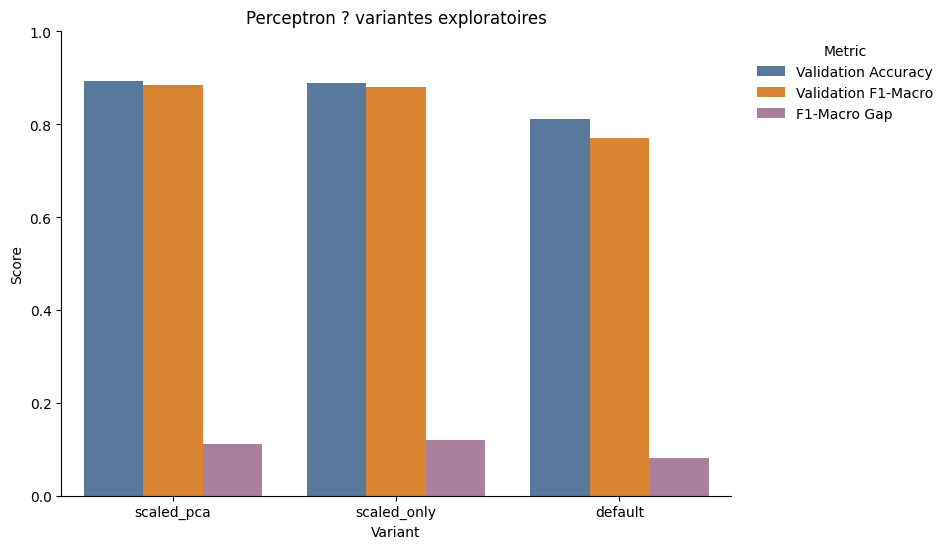

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Resultat confirmatoire tuned

Les cartes du `GridSearchCV` restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `tuned` obtenue en `nested CV`.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,tuned,nested_cv,tuned,0.9040,0.0220,0.8917,0.0271,NaN,NaN,NaN,NaN,41.5248,cv_n_jobs=1
1,scaled_pca,simple_cv,improved_untuned,0.8939,0.0258,0.8846,0.0263,0.9952,0.9947,0.1013,0.1100,1.0420,cv_n_jobs=1
2,scaled_only,simple_cv,improved_untuned,0.8889,0.0219,0.8792,0.0248,0.9987,0.9987,0.1098,0.1196,1.0273,cv_n_jobs=1
3,default,simple_cv,baseline,0.8111,0.0272,0.7700,0.0361,0.8874,0.8505,0.0763,0.0806,0.9480,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,0.9836,0.9841,0.9394,0.9351,8.0181,0.0025,0.8284
1,2,0.9924,0.9924,0.8889,0.8745,8.3662,0.0021,0.8573
2,3,0.9886,0.9886,0.8990,0.8842,8.3819,0.0021,0.8367
3,4,0.9912,0.9911,0.8838,0.8660,8.3555,0.0017,0.8402
4,5,0.9962,0.9962,0.9091,0.8987,8.3592,0.0020,0.8293


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_modele__alpha,param_modele__penalty,param_pca
10,1,0.8709,0.0107,0.6588,0.0010,l1,passthrough
5,2,0.8544,0.0257,0.3321,0.0001,l1,"PCA(n_components=0.99, random_state=42)"
7,3,0.8518,0.0031,0.1423,0.0010,NaN,"PCA(n_components=0.99, random_state=42)"
1,3,0.8518,0.0031,0.1509,0.0001,NaN,"PCA(n_components=0.99, random_state=42)"
6,5,0.8502,0.0074,0.1137,0.0010,NaN,passthrough
0,5,0.8502,0.0074,0.1624,0.0001,NaN,passthrough
2,7,0.8398,0.0061,0.2218,0.0001,l2,passthrough
3,8,0.8319,0.0197,0.1993,0.0001,l2,"PCA(n_components=0.99, random_state=42)"
4,9,0.8301,0.0304,0.4111,0.0001,l1,passthrough
11,10,0.8223,0.0398,0.4672,0.0010,l1,"PCA(n_components=0.99, random_state=42)"


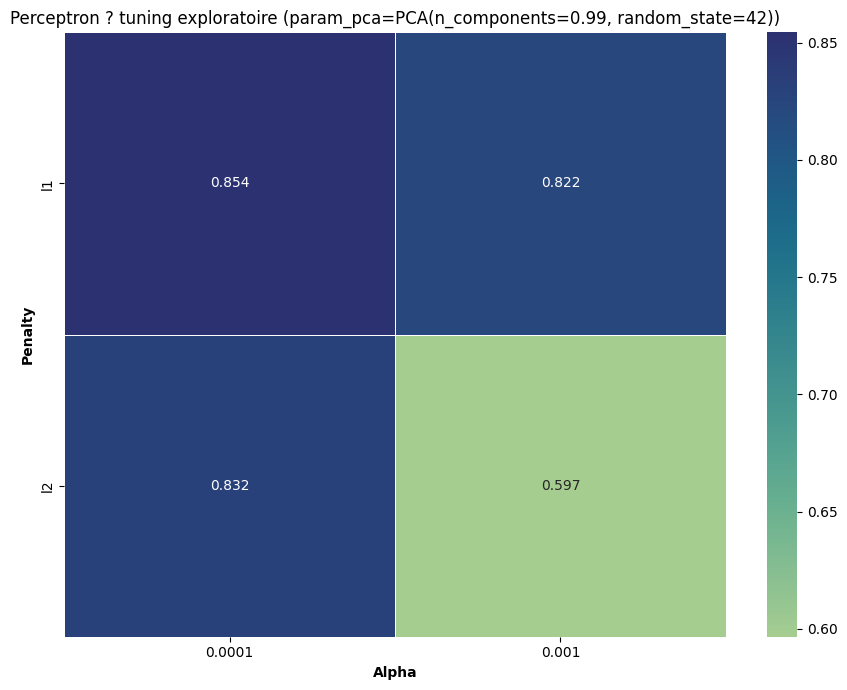

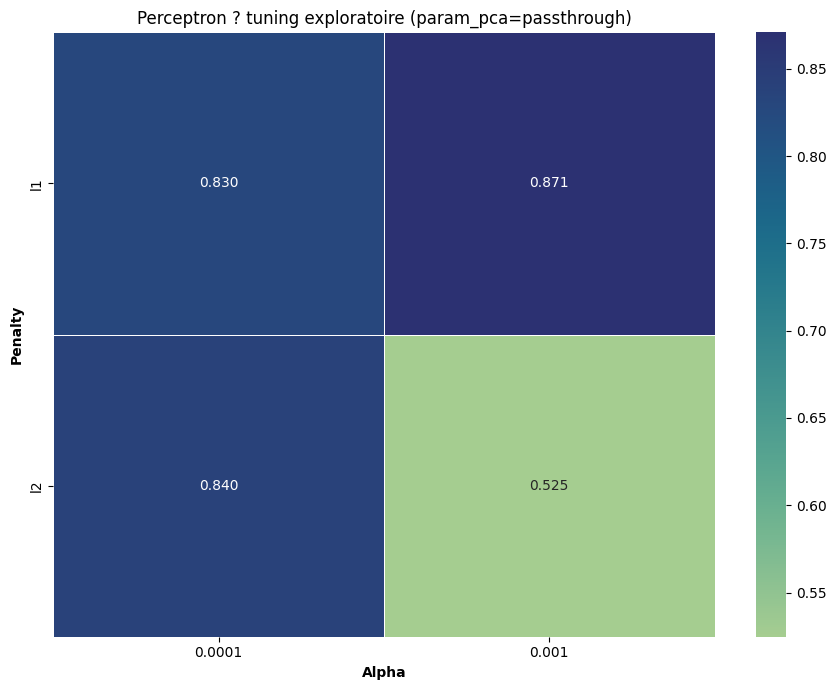

In [5]:
tuning = executer_tuning_confirmatoire(ctx, untuned_results)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} ? lecture exploratoire du tuning",
            )
            plt.show()


## 5. Verifications de validite scientifique

Cette section impose le meme contrat minimal dans tous les notebooks:
baseline dummy, test de bruit aleatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))

if MODEL_NAME == "mlp":
    mini_overfit = pd.DataFrame([verifier_overfit_petit_echantillon()])
    display(Markdown("**Sanity check additionnel MLP.** Ce test verifie qu'un reseau dense peut sur-apprendre un micro-echantillon synthetique."))
    display(mini_overfit.round(4))


**Note protocolaire.** Les variantes non tunees restent exploratoires; les figures refittees sur le sous-ensemble de developpement (80 %) aussi. Les predictions OOF de la variante tuned sont des diagnostics descriptifs confirmatoires, mais seul le score tuned en nested CV sert au classement final inter-modeles.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0101,0.0,0.0002,0.0,0.0101,0.0002,0.0012,0.0021,0.0307,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0061,0.0051,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des predictions `OOF` de la `nested CV` sont confirmatoires.
Les diagnostics issus d'un refit global ou du `grid search` complet sont explicitement exploratoires.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Quercus_Greggii,0.8000,0.4,0.5333,10,0.0010,0.6,0.9990
1,Alnus_Rubra,1.0000,0.6,0.7500,10,0.0000,0.4,1.0000
2,Quercus_Suber,0.8571,0.6,0.7059,10,0.0010,0.4,0.9990
3,Cytisus_Battandieri,0.8750,0.7,0.7778,10,0.0010,0.3,0.9990
4,Magnolia_Salicifolia,1.0000,0.7,0.8235,10,0.0000,0.3,1.0000
5,Prunus_X_Shmittii,1.0000,0.7,0.8235,10,0.0000,0.3,1.0000
6,Cornus_Macrophylla,0.8750,0.7,0.7778,10,0.0010,0.3,0.9990
7,Ilex_Cornuta,0.8750,0.7,0.7778,10,0.0010,0.3,0.9990
8,Quercus_Palustris,0.8750,0.7,0.7778,10,0.0010,0.3,0.9990
9,Quercus_Shumardii,0.6364,0.7,0.6667,10,0.0041,0.3,0.9959


,classe_vraie,classe_predite,nombre_erreurs
0,Cornus_Chinensis,Quercus_Imbricaria,2
1,Cornus_Macrophylla,Phildelphus,2
2,Lithocarpus_Cleistocarpus,Lithocarpus_Edulis,2
3,Lithocarpus_Edulis,Lithocarpus_Cleistocarpus,2
4,Magnolia_Salicifolia,Magnolia_Heptapeta,2
5,Quercus_Kewensis,Quercus_Phillyraeoides,2
6,Quercus_Palustris,Quercus_Shumardii,2
7,Quercus_Texana,Quercus_Coccinea,2
8,Quercus_Trojana,Quercus_x_Hispanica,2
9,Acer_Capillipes,Acer_Rufinerve,1


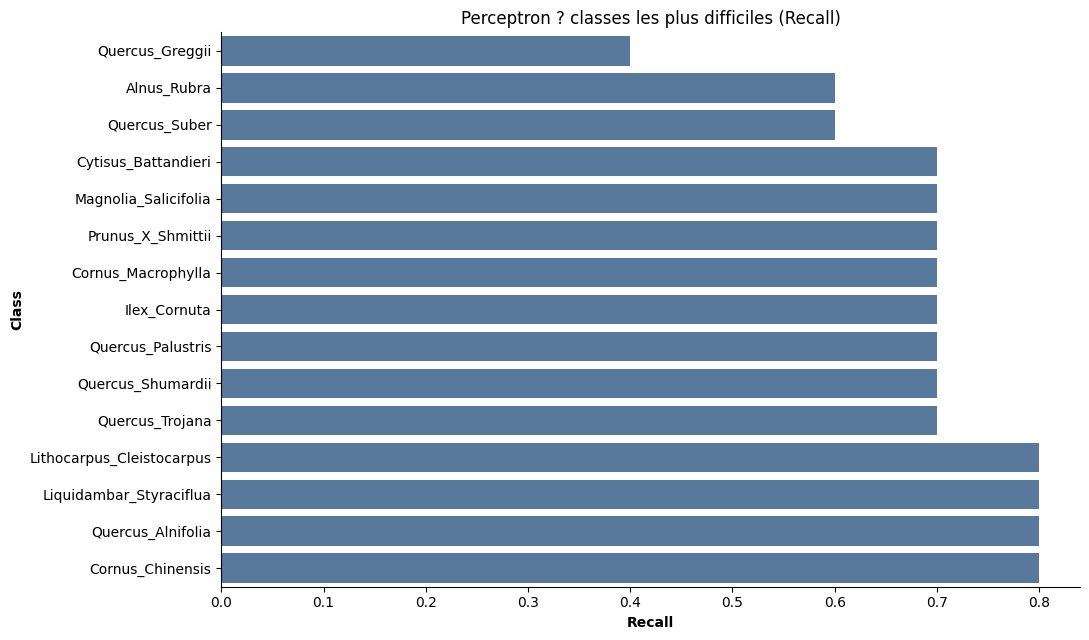

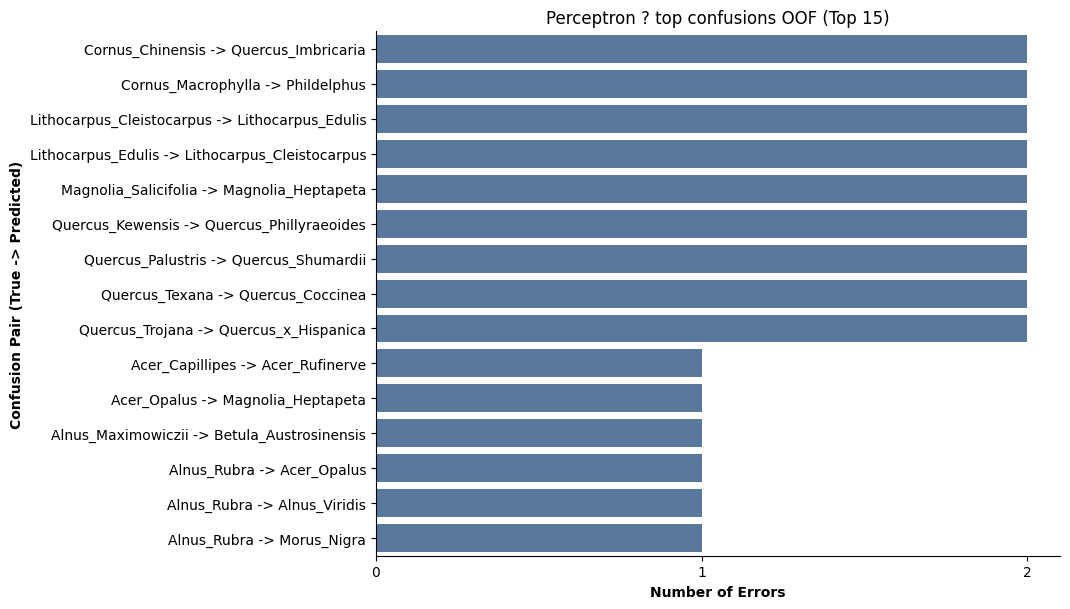

_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions OOF",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance OOF",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? reliability diagram OOF",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.7700,0.8111,0.0806,Betula_Pendula -> Quercus_Coccifera,3
1,scaled_only,improved_untuned,0.8792,0.8889,0.1196,Pterocarya_Stenoptera -> Prunus_X_Shmittii,2
2,scaled_pca,improved_untuned,0.8846,0.8939,0.1100,Cornus_Macrophylla -> Phildelphus,2
3,tuned,tuned,0.8917,0.9040,NaN,Cornus_Chinensis -> Quercus_Imbricaria,2


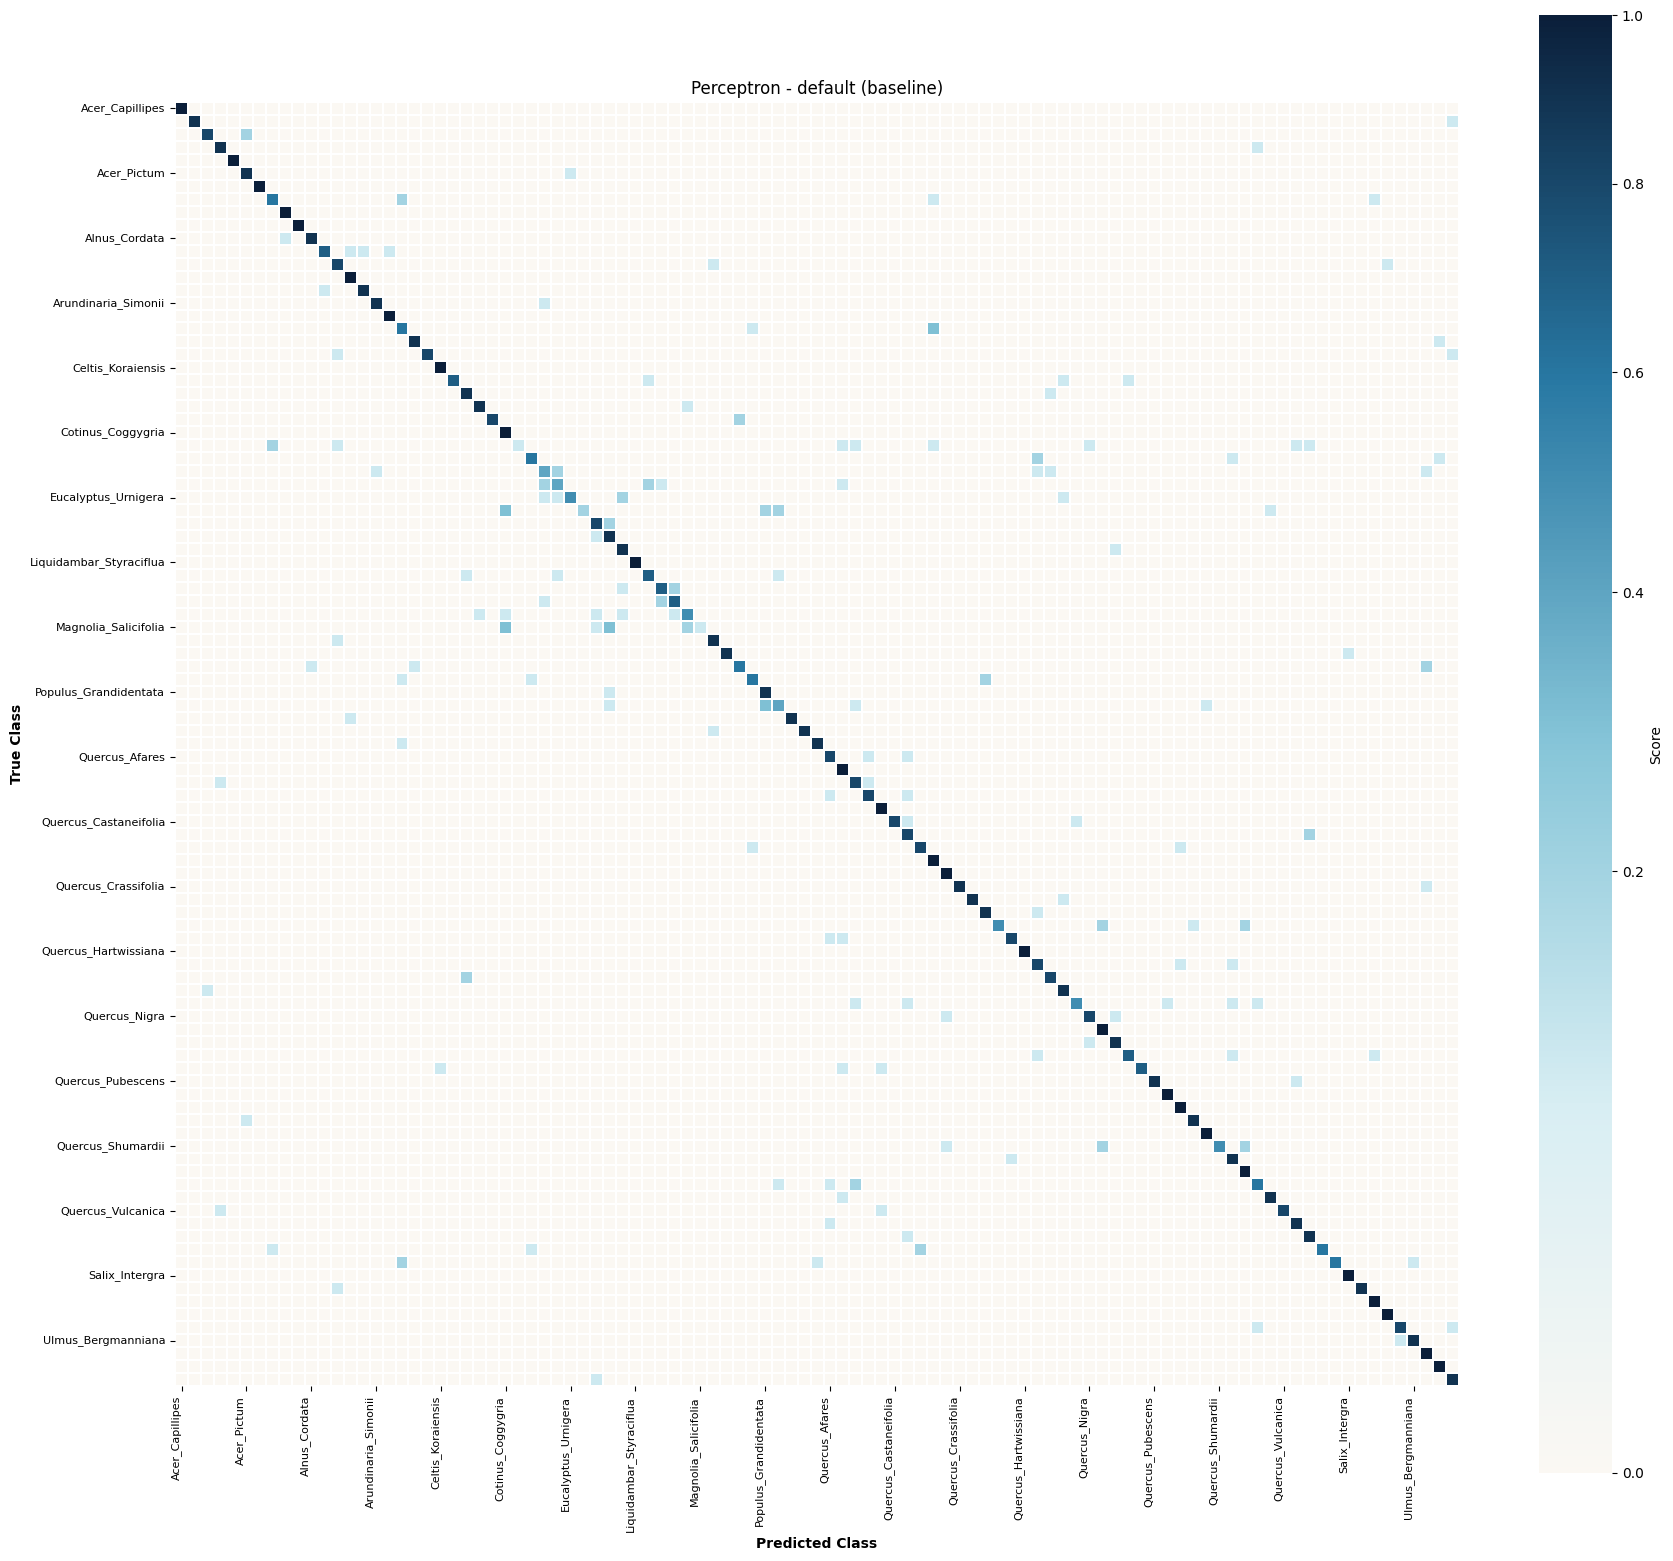

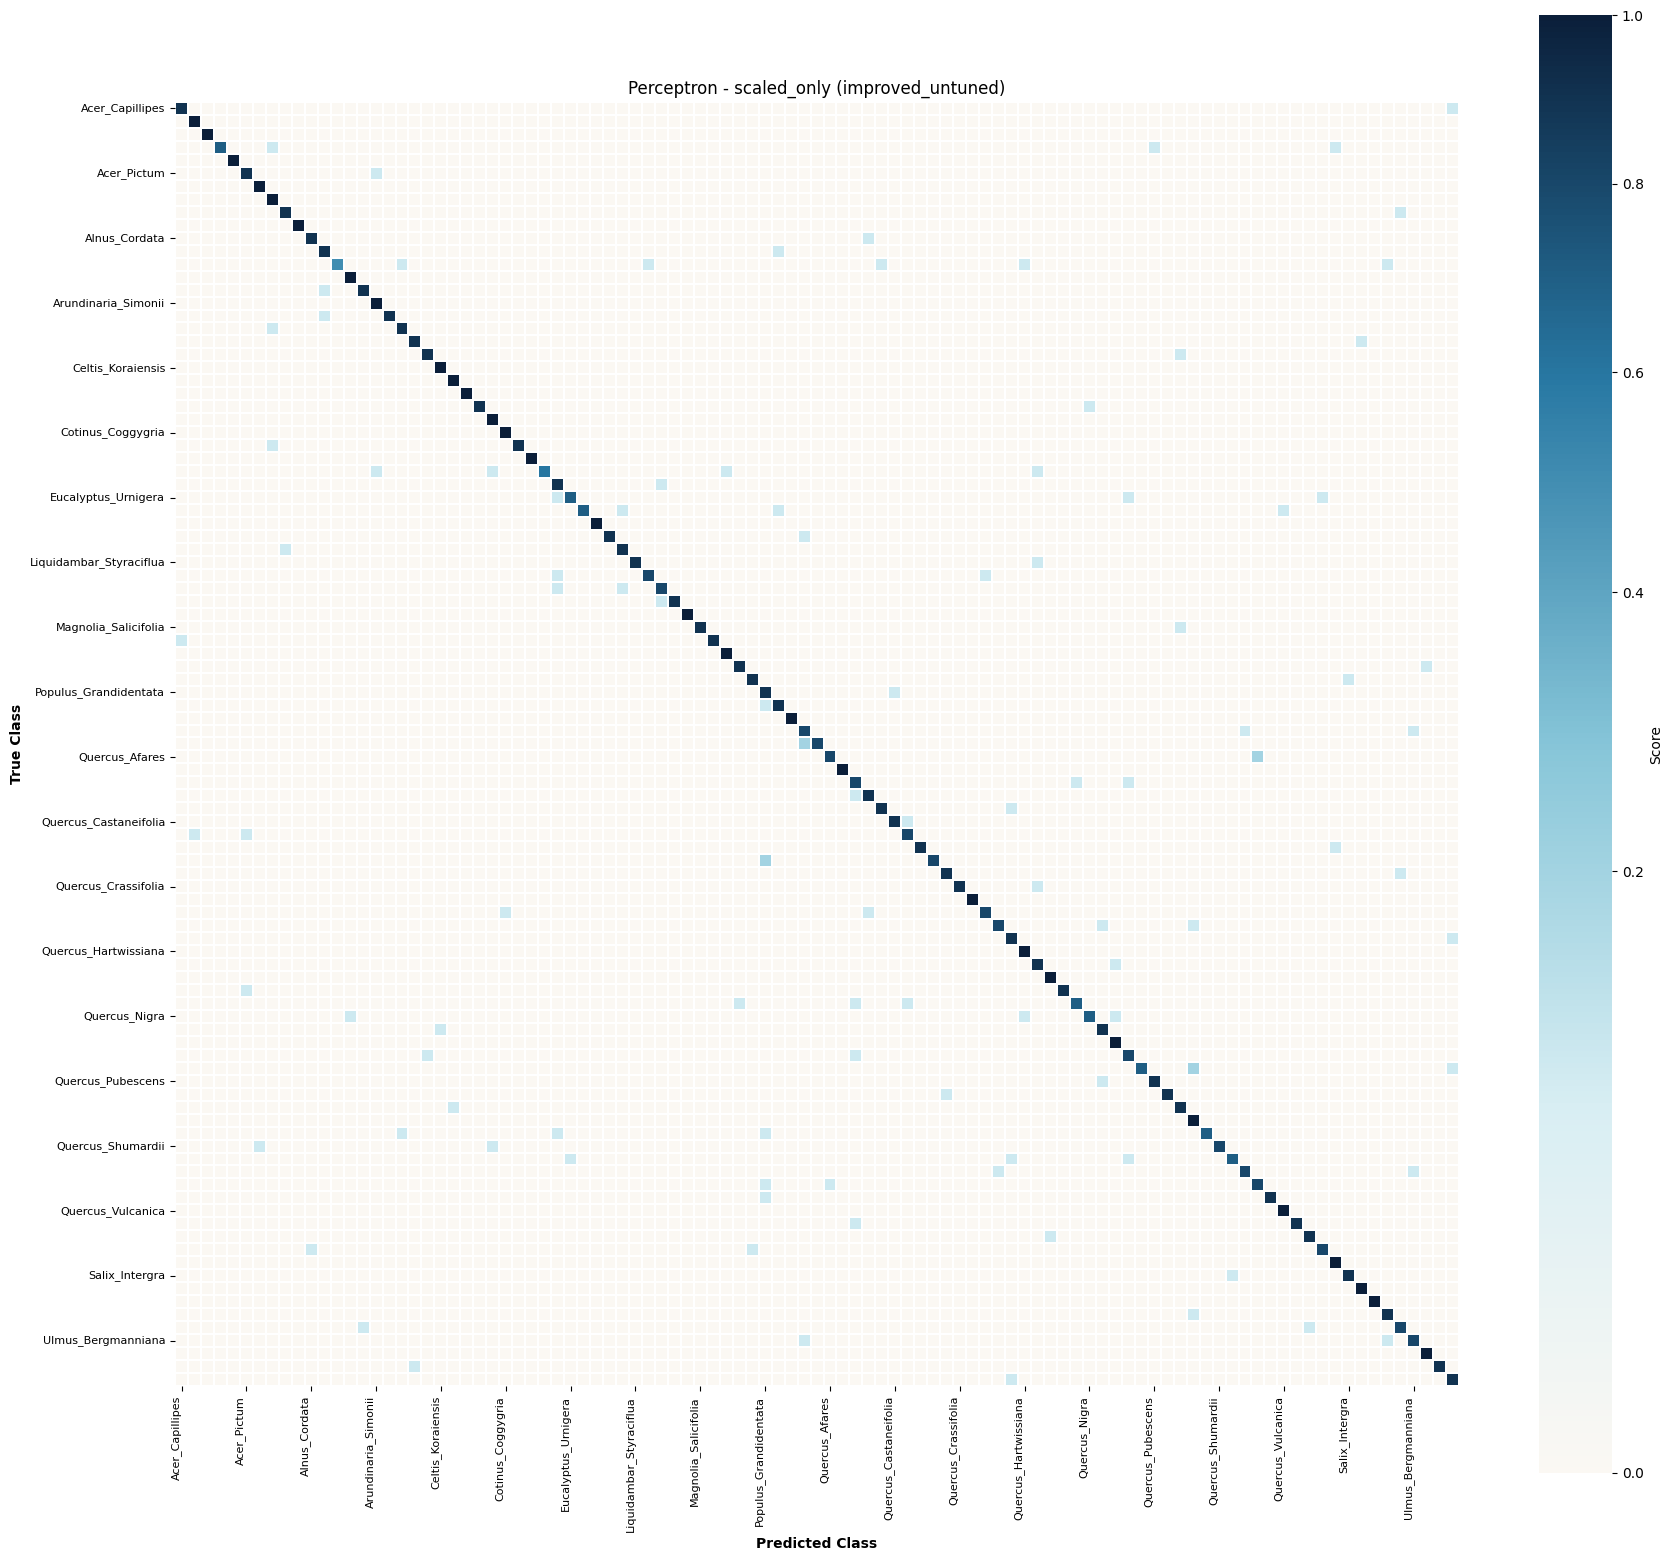

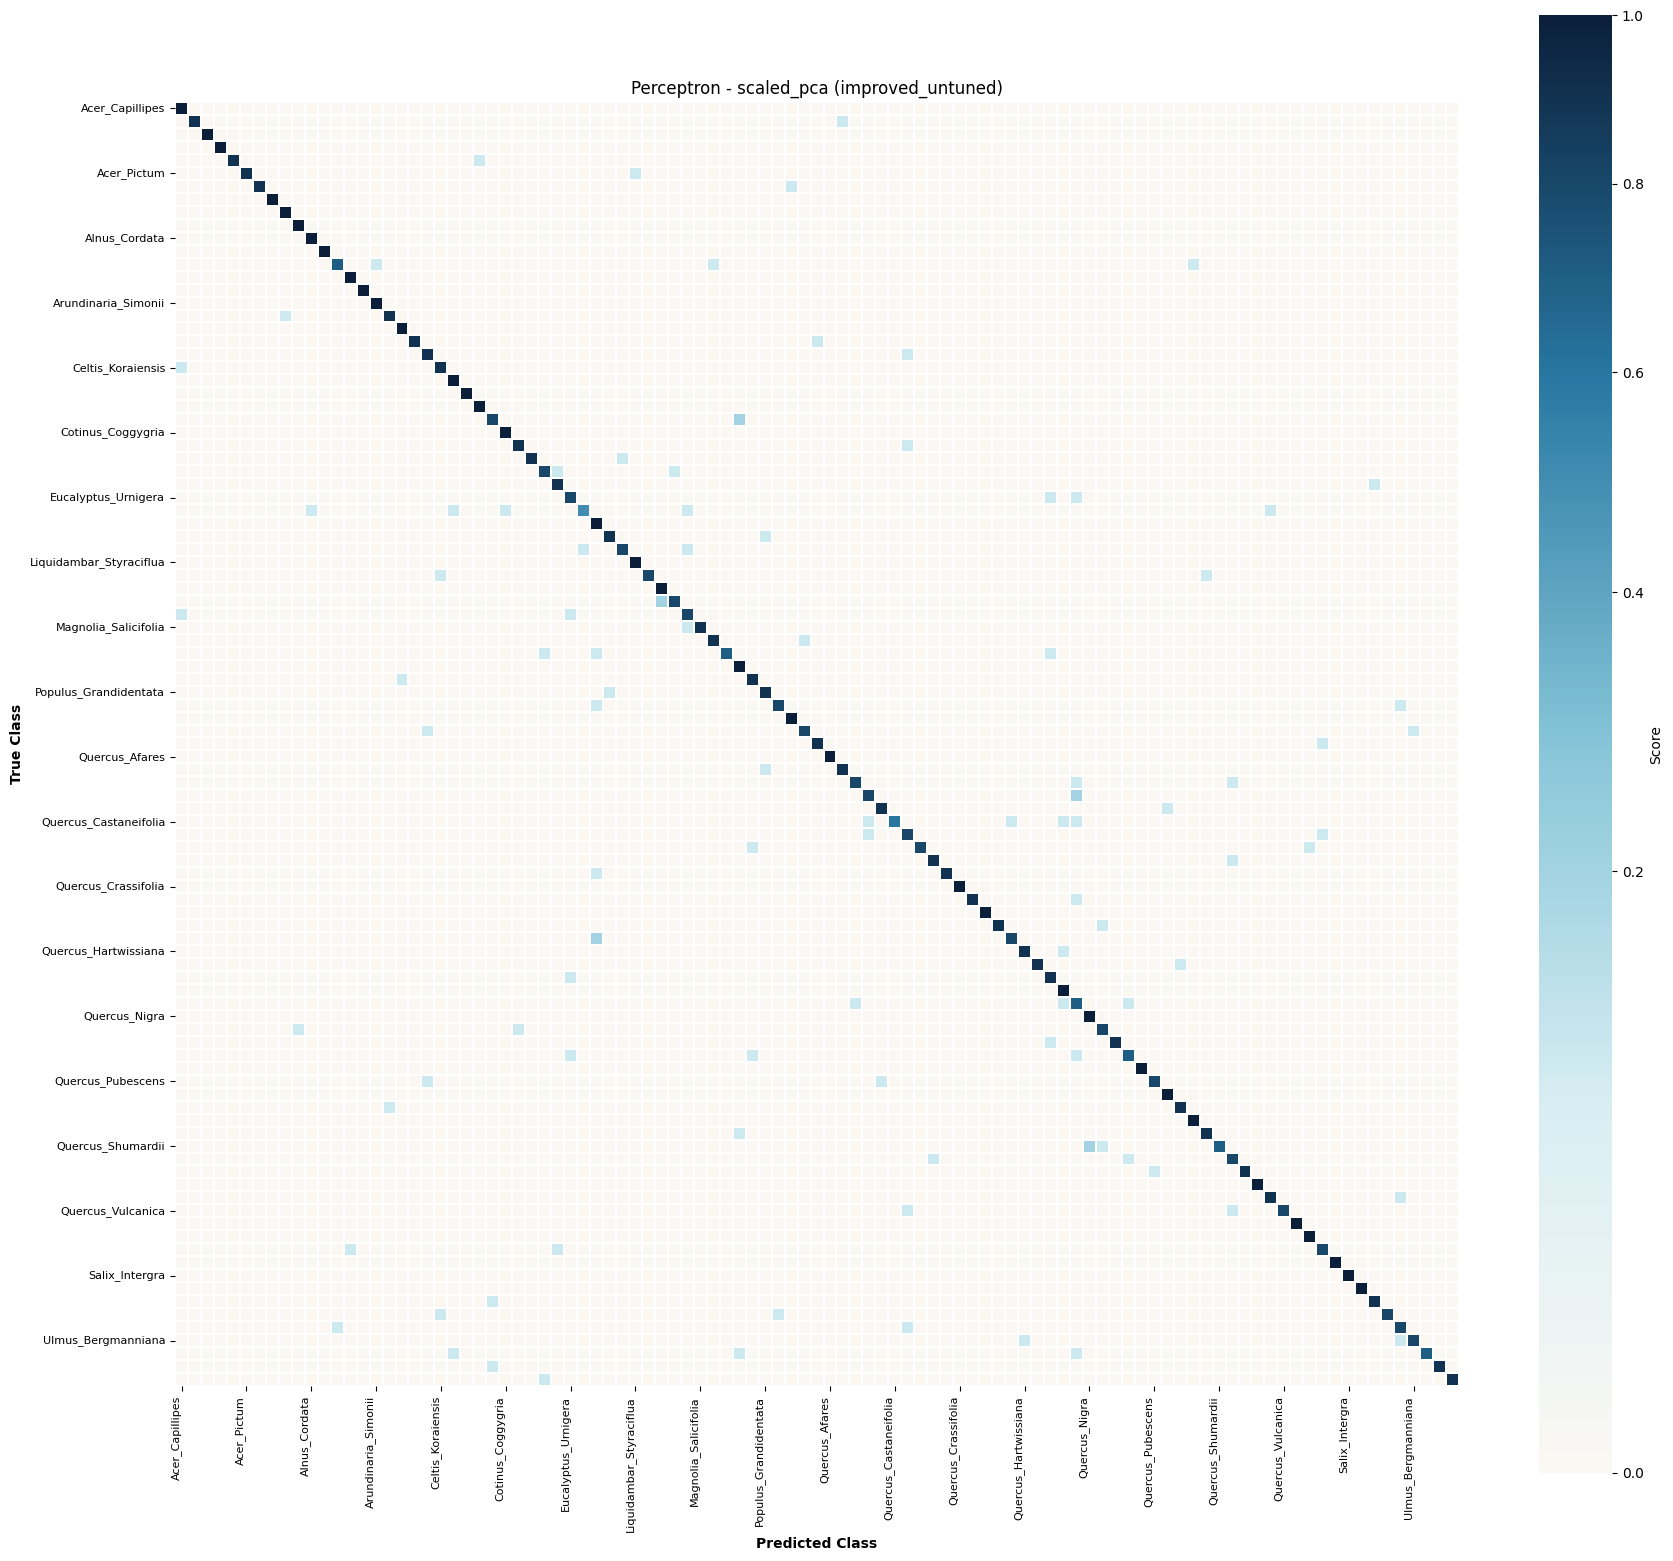

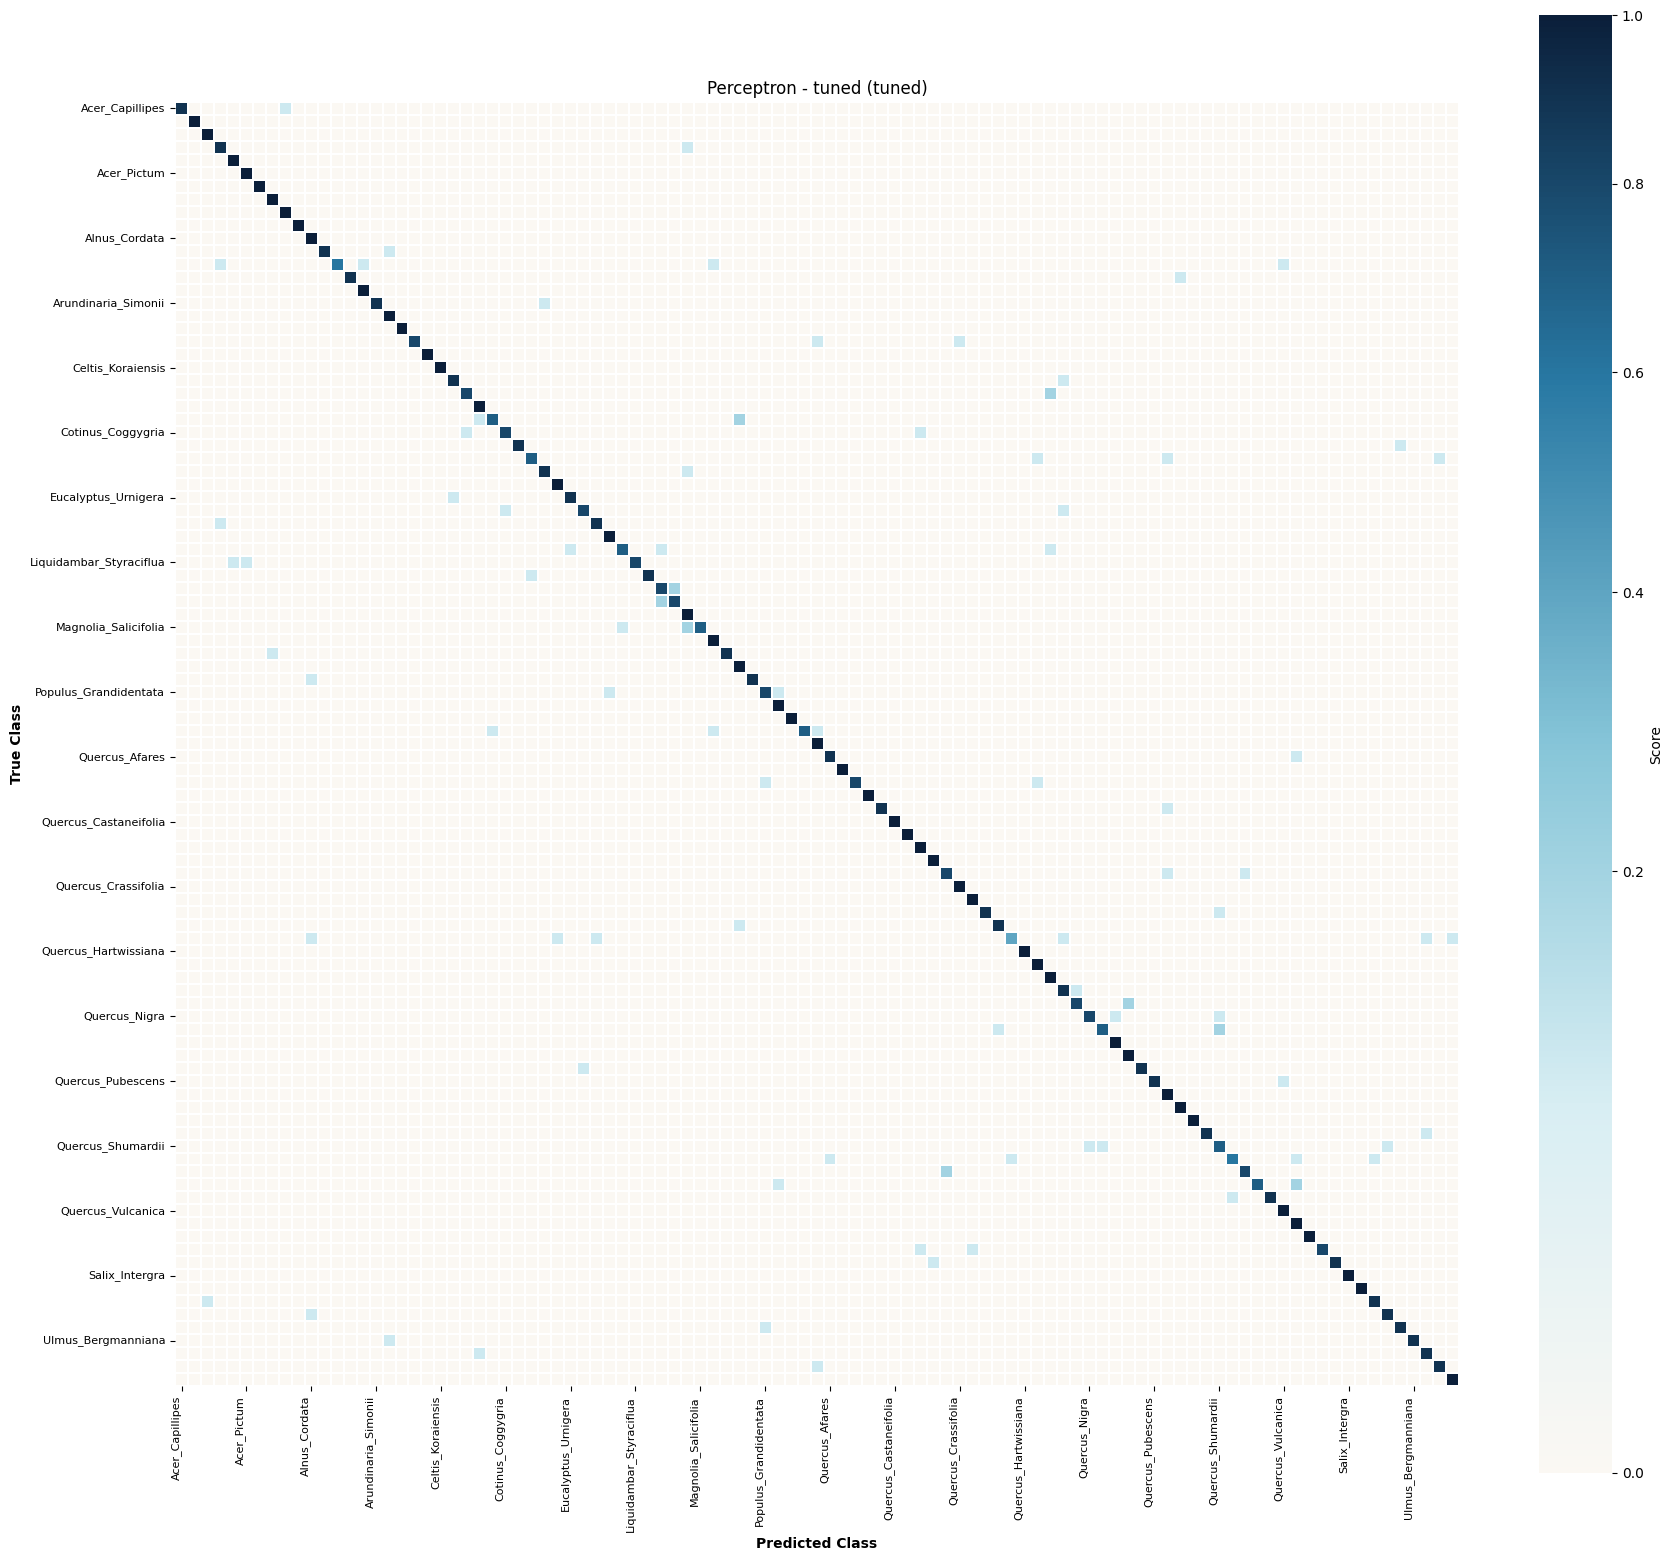

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
        root=OUTPUT_ROOT,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


### Decision function — diagnostic exploratoire

Histogramme de la fonction de decision du Perceptron, refitte sur le sous-ensemble de developpement (80 %).
Ce diagnostic est **exploratoire** (in-sample) — il illustre la separation lineaire apprise, pas la performance generalisable.

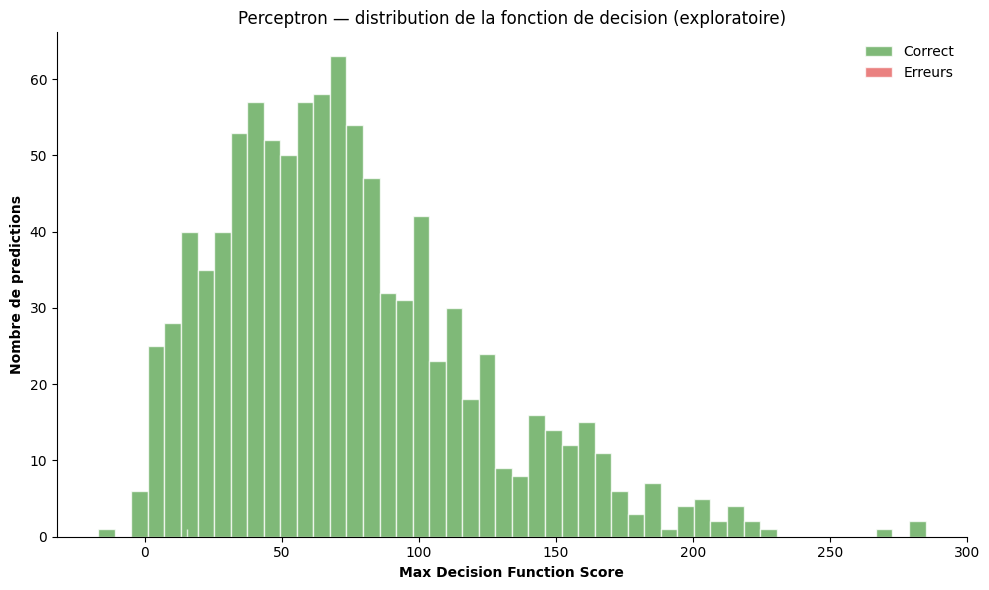

In [9]:
from src.models.pipelines import creer_pipeline

df_hist = decision_function_histogram(
    creer_pipeline("perceptron", utiliser_pca=False),
    X, y,
)
tracer_decision_function_histogram(
    df_hist,
    titre=f"{definition['nom_affiche']} — distribution de la fonction de decision (exploratoire)",
)
plt.show()

## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [10]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
default_row = untuned_table.loc[untuned_table["variante"] == "default"].iloc[0]
lignes = [
    f"- Meilleure variante non tunee: `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire `tuned` en nested CV: F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

if "scaled_only" in untuned_table["variante"].values:
    scaled_row = untuned_table.loc[untuned_table["variante"] == "scaled_only"].iloc[0]
    delta_scaling = scaled_row["val_f1_macro_mean"] - default_row["val_f1_macro_mean"]
    lignes.append(
        f"- Effet du scaling sur l'exploration: delta F1-macro = `{delta_scaling:+.4f}` entre `default` et `scaled_only`."
    )

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- Le tuning confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport a la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La nested CV donne une estimation plus conservative que l'exploration simple CV (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunee: `scaled_pca` avec F1-macro = `0.8846`.
- Estimation confirmatoire `tuned` en nested CV: F1-macro = `0.8917` et accuracy = `0.9040`.
- Effet du scaling sur l'exploration: delta F1-macro = `+0.1092` entre `default` et `scaled_only`.
- Le tuning confirme un gain de `+0.0071` en F1-macro par rapport a la meilleure variante exploratoire.

### Figure finale des variantes pour le rapport

Cette cellule lit les metriques canoniques dans `results/<modele>/metrics/`, reconstruit le tableau final des variantes et regenere la figure de synthese du rapport, en incluant explicitement la variante `tuned`.

In [ ]:
from pathlib import Path

from src.notebook_support import (
    charger_tableau_variantes_modele,
    construire_tableau_variantes_rapport,
)
from src.plots import tracer_comparaison_variantes_rapport

summary_table_report = charger_tableau_variantes_modele("perceptron")
display(construire_tableau_variantes_rapport(summary_table_report).round(4))

ax = tracer_comparaison_variantes_rapport(
    summary_table_report,
    titre="Perceptron - Variantes exploratoires et tuned",
)
output_path = Path("docs/figures/figA2b_comparaison_perceptron.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(output_path, dpi=170, bbox_inches="tight")
output_path


## 8. Verification secondaire sur holdout

Cette section reste strictement additive. Le holdout gele de `20 %` n'intervient ni dans le choix des variantes, ni dans le tuning, ni dans le classement principal.
Il sert uniquement a corroborer, sur un sous-ensemble jamais vu pendant la modelisation, l'ecart entre la variante `tuned` et la meilleure variante non tunee retenue sur le jeu de developpement.


In [ ]:
holdout_table = construire_tableau_holdout_secondaire(tuning["metrics"])
if holdout_table.empty:
    display(Markdown("_Aucune corroboration holdout publiee pour ce modele._"))
else:
    display(holdout_table.round(4))

    axe_holdout = tracer_comparaison_variantes(
        holdout_table,
        ["f1_macro_holdout", "accuracy_holdout"],
        titre=f"{definition['nom_affiche']} - verification secondaire sur holdout",
    )
    axe_holdout.set_ylim(0.0, 1.0)


    reference_row = holdout_table.loc[holdout_table["role"] == "reference"].iloc[0]
    tuned_holdout_row = holdout_table.loc[holdout_table["role"] == "tuned"].iloc[0]
    delta_holdout = tuned_holdout_row["f1_macro_holdout"] - reference_row["f1_macro_holdout"]
    lignes_holdout = [
        f"- Reference holdout: `{reference_row['variante']}` avec F1-macro = `{reference_row['f1_macro_holdout']:.4f}`.",
        f"- Variante `tuned` sur holdout: F1-macro = `{tuned_holdout_row['f1_macro_holdout']:.4f}` et accuracy = `{tuned_holdout_row['accuracy_holdout']:.4f}`.",
        f"- Ecart holdout `tuned - reference`: `{delta_holdout:+.4f}` en F1-macro.",
        "- Cette lecture reste secondaire : le classement principal du rapport repose toujours sur la nested CV du jeu de developpement.",
    ]
    display(Markdown("\n".join(lignes_holdout)))
